In [1]:
import scanpy as sc
import pandas as pd
import torch
import scvi

In [2]:
# https://figshare.com/ndownloader/files/24539942
anndata = sc.read_h5ad("data/Lung_atlas_public.h5ad")
anndata

AnnData object with n_obs × n_vars = 32472 × 15148
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor'
    layers: 'counts'

In [3]:
anndata.raw = anndata  # keep full dimension safe
sc.pp.highly_variable_genes(
    anndata,
    flavor="seurat_v3",
    n_top_genes=2000,
    layer="counts",
    batch_key="batch",
    subset=True,
)

/anaconda3/envs/bibola/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


In [4]:
batch_ids =pd.Series(
    range(len(anndata.obs["batch"].cat.categories)),
    index=anndata.obs["batch"].cat.categories
)
batch_ids

1      0
2      1
3      2
4      3
5      4
6      5
A1     6
A2     7
A3     8
A4     9
A5    10
A6    11
B1    12
B2    13
B3    14
B4    15
dtype: int64

In [5]:
anndata.obs["batch_int"] = anndata.obs["batch"].map(batch_ids).astype(int)
anndata.obs

,dataset,location,nGene,nUMI,patientGroup,percent.mito,protocol,sanger_type,size_factors,sampling_method,batch,cell_type,donor,batch_int
index,,,,,,,,,,,,,,
GAGGGGCCAGCC,Dropseq_transplant,Dropseq_lower,249,355,nan,0.019718,drop-seq,drop-seq,0.381231,Transplant,B1,Type 2,B1,12
ACATAGATAGGC,Dropseq_transplant,Dropseq_lower,582,987,nan,0.044580,drop-seq,drop-seq,1.081643,Transplant,B1,Type 2,B1,12
ATCGACGCGGCA,Dropseq_transplant,Dropseq_lower,292,490,nan,0.026531,drop-seq,drop-seq,0.497352,Transplant,B1,Type 2,B1,12
CCAGCTTAGGTT,Dropseq_transplant,Dropseq_lower,1057,1806,nan,0.035437,drop-seq,drop-seq,2.172617,Transplant,B1,Type 2,B1,12
TCATAGAGTCCT,Dropseq_transplant,Dropseq_lower,716,1378,nan,0.020319,drop-seq,drop-seq,1.197578,Transplant,B1,Type 2,B1,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LungTranscriptome7239219_LungTranscriptome7239219GGGCATCCACCAACCG,10x_Transplant,Transplant,1178,3245,Parenchyma,0.011896,10x v2,other,0.775650,Transplant,5,Mast cell,5,4
LungTranscriptome7239219_LungTranscriptome7239219TGCTGCTAGCAATCTC,10x_Transplant,Transplant,1919,5984,Parenchyma,0.018747,10x v2,other,0.982236,Transplant,5,Mast cell,5,4
LungTranscriptome7239213_GACTGCGTCCTGCCAT,10x_Transplant,Transplant,4411,25233,Parenchyma,0.010489,10x v2,other,1.235763,Transplant,3,Mast cell,3,2


In [6]:
anndata.obs.groupby("cell_type").size()

/tmp/ipykernel_1125653/3276086893.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  anndata.obs.groupby("cell_type").size()


cell_type
B cell                  1353
Basal 1                 1972
Basal 2                 3072
Ciliated                3155
Dendritic cell          1367
Endothelium              988
Fibroblast               733
Ionocytes                 46
Lymphatic                341
Macrophage              7492
Mast cell                889
Neutrophil_CD14_high    1626
Neutrophils_IL1R2        472
Secretory               2459
T/NK cell               1797
Type 1                   424
Type 2                  4286
dtype: int64

In [15]:
sc.pp.pca(anndata)
sc.pp.neighbors(anndata)
sc.tl.umap(anndata)

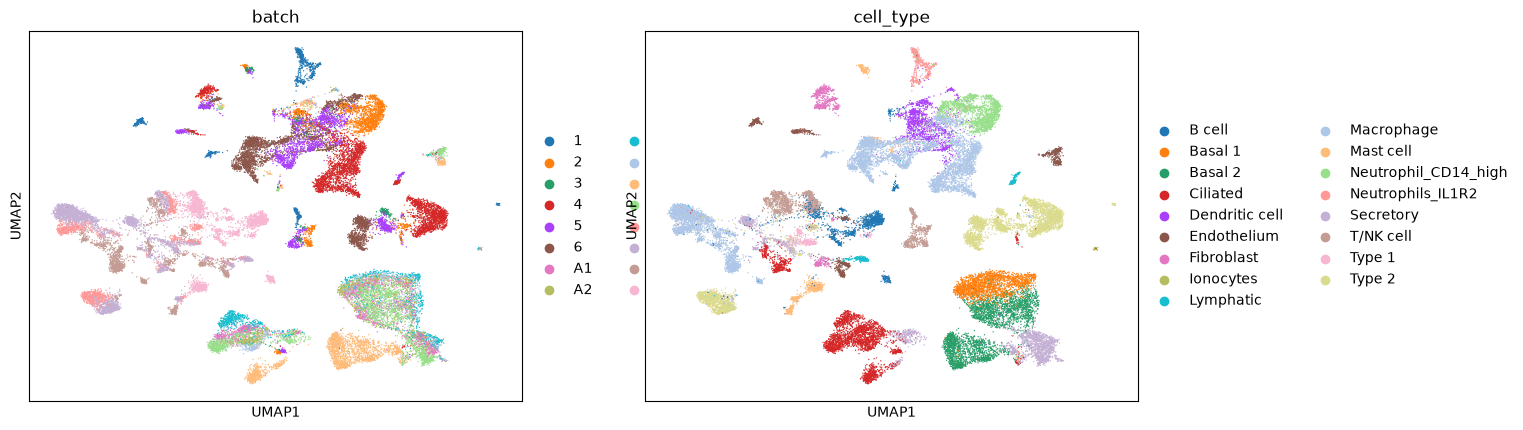

In [16]:
# original UMAP (without batch correction)
sc.pl.umap(anndata, color=["batch", "cell_type"], palette=sc.pl.palettes.vega_20_scanpy)

In [9]:
scvi.model.SCVI.setup_anndata(anndata, layer="counts", batch_key="batch")

/anaconda3/envs/bibola/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [10]:
scvi_model = scvi.model.SCVI(anndata, n_layers=2, n_latent=30, gene_likelihood="nb")
scvi_model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 30, n_layers: 2, dropout_rate: 0.1, dispersion: gene, gene_likelihood: nb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [11]:
scvi_model.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/anaconda3/envs/bibola/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLo

Training:   0%|          | 0/246 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=246` reached.


In [17]:
SCVI_LATENT_KEY = "X_scVI"
anndata.obsm[SCVI_LATENT_KEY] = scvi_model.get_latent_representation()
anndata

AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'batch_int', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'batch_colors', 'cell_type_colors', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'X_scVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [18]:
sc.pp.neighbors(anndata, use_rep=SCVI_LATENT_KEY, key_added="neighbors_scVI")
sc.tl.umap(anndata, neighbors_key="neighbors_scVI", key_added="umap_scVI")

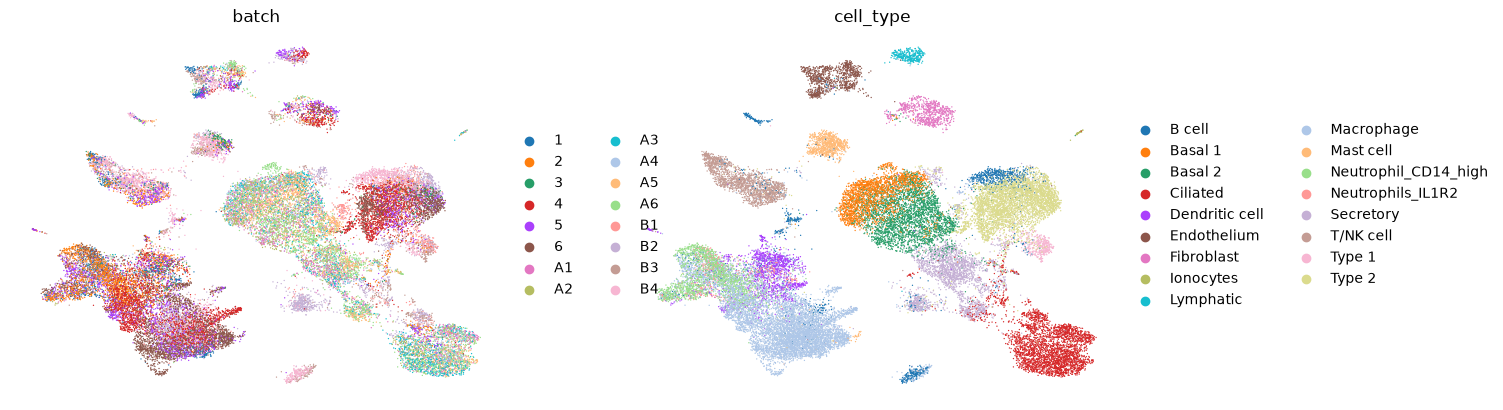

In [19]:
sc.pl.embedding(
    anndata,
    color=["batch", "cell_type"],
    basis="umap_scVI",
    frameon=False,
)

In [20]:
import torch
from sklearn.model_selection import RepeatedStratifiedKFold
from bibola.MLP import MultiBatchesMLP

In [ ]:
batch_correction_model = MultiBatchesMLP(
    in_channels=anndata.obsm["X_pca"].shape[1],
    hidden_channels=[1024,],
    out_channels=30, # as the latent dimension of scVI
    n_batches=anndata.obs["batch"].nunique(),
    dropout=0.1,
)
batch_correction_model.train()

MultiBatchesMLP(
  (mlps): ModuleList(
    (0-15): 16 x BatchMLP(
      (sequential): Sequential(
        (0): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (1): MLP(
          (0): Linear(in_features=50, out_features=1024, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
        (2): Linear(in_features=1024, out_features=30, bias=True)
      )
    )
  )
)

In [24]:
N_MINIBATCHES = 10
N_EPOCHS = 5

loader = RepeatedStratifiedKFold(
    n_splits=N_MINIBATCHES, # number of minibatches to train on
    n_repeats=N_EPOCHS, # number of epochs to train on
    random_state=42
)
loader

RepeatedStratifiedKFold(n_repeats=5, n_splits=10, random_state=42)

In [30]:
batch_correction_model.train()

i = 0
for _, train_ids in loader.split(anndata.obs.index, anndata.obs["batch_int"]):
    if i%N_MINIBATCHES == 0:
        print(f"####### EPOCH {1+ i//N_MINIBATCHES} #######")
    
    X_train = anndata.obsm["X_pca"][train_ids]
    X_train = torch.tensor(X_train, dtype=torch.float32)
    
    batch_train = anndata.obs["batch_int"].values[train_ids].astype(int)
    batch_train = torch.tensor(batch_train, dtype=torch.int32)
    
    batch_correction_model.fit(
        X_train, batch_train, epochs=1, lr=1e-4,
        print_every=1, k_inter=5, k_intra=100, norm=1,
        loss_weights={"abs_lisa_loss":.25, "topology_loss": .75, "knn_loss": 2.}
    )

    i+=1

batch_correction_model.eval()

####### EPOCH 1 #######
Epoch 0, Loss: -0.6911537647247314
Epoch 0, Loss: -0.7123949527740479
Epoch 0, Loss: -0.729989230632782
Epoch 0, Loss: -0.7253686785697937
Epoch 0, Loss: -0.7523524761199951
Epoch 0, Loss: -0.767066240310669
Epoch 0, Loss: -0.7434101700782776
Epoch 0, Loss: -0.7701515555381775
Epoch 0, Loss: -0.7785751223564148
Epoch 0, Loss: -0.7955706119537354
####### EPOCH 2 #######
Epoch 0, Loss: -0.8100330233573914
Epoch 0, Loss: -0.8210000991821289
Epoch 0, Loss: -0.8179503083229065
Epoch 0, Loss: -0.8573718070983887
Epoch 0, Loss: -0.8503408432006836
Epoch 0, Loss: -0.8629521131515503
Epoch 0, Loss: -0.8938052654266357
Epoch 0, Loss: -0.9018067121505737
Epoch 0, Loss: -0.8967176079750061
Epoch 0, Loss: -0.9475991129875183
####### EPOCH 3 #######
Epoch 0, Loss: -0.9442280530929565
Epoch 0, Loss: -0.9594666957855225
Epoch 0, Loss: -0.9466315507888794
Epoch 0, Loss: -1.0015177726745605
Epoch 0, Loss: -1.0216306447982788
Epoch 0, Loss: -1.046363353729248
Epoch 0, Loss: -1.084

MultiBatchesMLP(
  (mlps): ModuleList(
    (0-15): 16 x BatchMLP(
      (sequential): Sequential(
        (0): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (1): MLP(
          (0): Linear(in_features=50, out_features=1024, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
        (2): Linear(in_features=1024, out_features=30, bias=True)
      )
    )
  )
)

In [32]:
anndata.obsm["X_corrected"] = batch_correction_model(
    torch.tensor(anndata.obsm["X_pca"], dtype=torch.float32),
    torch.tensor(anndata.obs["batch_int"].values.astype(int), dtype=torch.int32)
).detach().numpy()

from sklearn.decomposition import PCA

# we apply PCA to reduce the collinearity after the batch correction.
pca_model = PCA(n_components=batch_correction_model.out_channels)
anndata.obsm["X_corrected"] = pca_model.fit_transform(anndata.obsm["X_corrected"])
anndata

AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'batch_int', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'batch_colors', 'cell_type_colors', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors_scVI', 'umap_scVI'
    obsm: 'X_pca', 'X_umap', 'X_scVI', 'umap_scVI', 'X_corrected'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'neighbors_scVI_distances', 'neighbors_scVI_connectivities'

In [33]:
sc.pp.neighbors(anndata, use_rep="X_corrected", key_added="neighbors_corrected")
sc.tl.umap(anndata, neighbors_key="neighbors_corrected", key_added="umap_corrected")
anndata

AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'batch_int', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'batch_colors', 'cell_type_colors', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors_scVI', 'umap_scVI', 'neighbors_corrected', 'umap_corrected'
    obsm: 'X_pca', 'X_umap', 'X_scVI', 'umap_scVI', 'X_corrected', 'umap_corrected'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'neighbors_scVI_distances', 'neighbors_scVI_connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities'

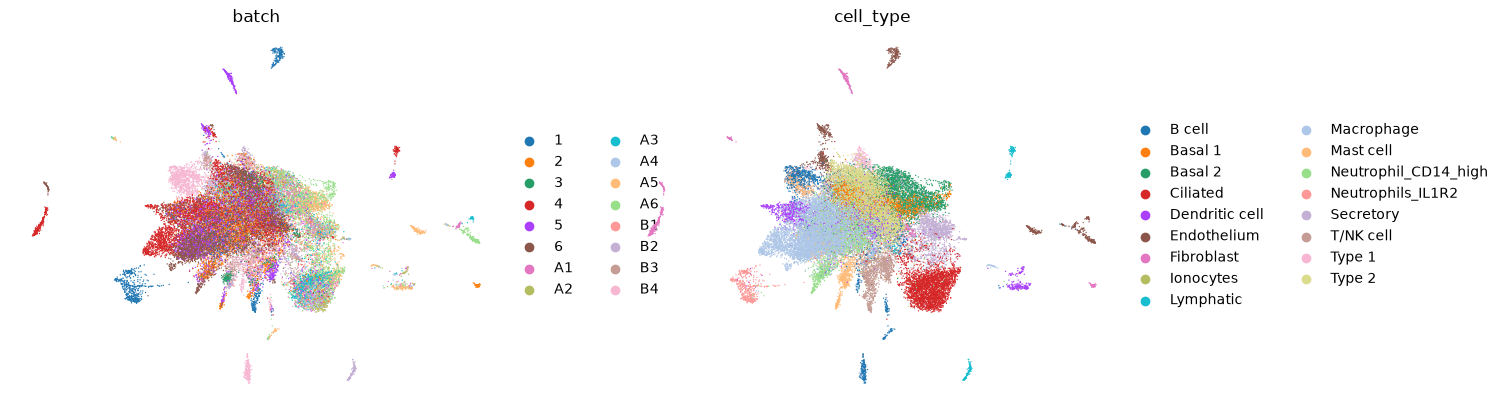

In [34]:
sc.pl.embedding(
    anndata,
    color=["batch", "cell_type"],
    basis="umap_corrected",
    frameon=False,
)
# UMAP after batch correction via bibola

In [ ]:
from harmonypy import run_harmony
anndata.obsm["X_pca_harmony"] = run_harmony(anndata.obsm["X_pca"], anndata.obs, "batch").Z_corr# Basal
# ├── Basal 1
# ├── Basal 2
# │
# ├── Secretory
# │     └── Ciliated
# │
# └── Ionocytes
anndata.obsm["X_pca_harmony"]

2026-08-06 14:52:16,298 - harmonypy - INFO - Running Harmony
2026-08-06 14:52:16,299 - harmonypy - INFO -   Parameters:
2026-08-06 14:52:16,299 - harmonypy - INFO -     max_iter_harmony: 10
2026-08-06 14:52:16,299 - harmonypy - INFO -     max_iter_kmeans: 4
2026-08-06 14:52:16,299 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-08-06 14:52:16,300 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-08-06 14:52:16,300 - harmonypy - INFO -     nclust: 100
2026-08-06 14:52:16,300 - harmonypy - INFO -     block_size: 0.05
2026-08-06 14:52:16,300 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-08-06 14:52:16,301 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-08-06 14:52:16,301 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-08-06 14:52:16,302 - harmonypy - INFO -     verbose: True
2026-08-06 14:52:16,302 - harmonypy - INFO -     random_state: 0
2026-08-06 14:52:16,302 - harmonypy - INFO -   Data: 50 PCs × 32472 cells
2026-08-

array([[ 1.65743005,  7.52497435,  0.25517264, ...,  0.11654027,
        -0.53503984, -0.22242148],
       [ 0.88072044,  7.19741344,  0.22153081, ..., -0.32729483,
         0.45369196,  0.82945728],
       [ 0.94033009,  7.96733856,  0.92544198, ..., -0.43930417,
        -0.29741594, -0.41001469],
       ...,
       [ 5.03172207, -4.03623343, -1.80268908, ...,  0.6981867 ,
         0.54427189, -0.55465281],
       [ 4.65386486, -4.91154718, -0.5864678 , ...,  0.91752118,
        -0.1319973 ,  0.12151333],
       [ 5.21427965, -4.02160215, -1.61945224, ...,  1.01830983,
         0.03995328, -0.3437866 ]], shape=(32472, 50))

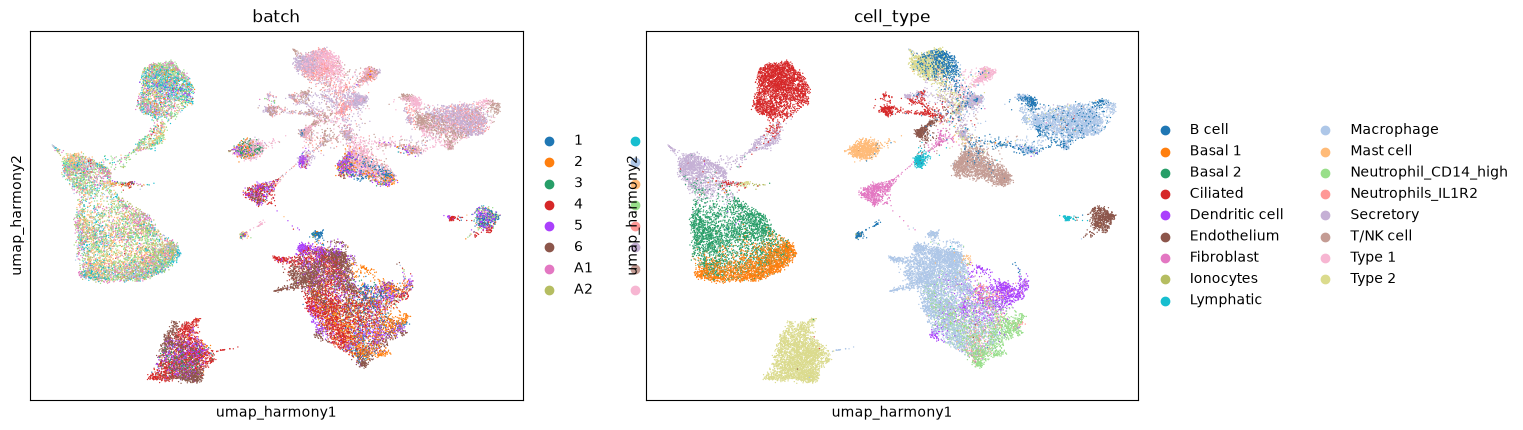

In [36]:
sc.pp.neighbors(anndata, use_rep="X_pca_harmony", key_added="neighbors_harmony")
sc.tl.umap(anndata, neighbors_key="neighbors_harmony", key_added="umap_harmony")
sc.pl.embedding(anndata, color=["batch", "cell_type"], palette=sc.pl.palettes.vega_20_scanpy, basis="umap_harmony")
# UMAP after batch correction via harmony

In [37]:
batch_correction_model = MultiBatchesMLP(
    in_channels=anndata.obsm["X_pca_harmony"].shape[1],
    hidden_channels=[1024,],
    out_channels=30,
    n_batches=anndata.obs["batch"].nunique(),
    dropout=0.1,
)
batch_correction_model.train()

MultiBatchesMLP(
  (mlps): ModuleList(
    (0-15): 16 x BatchMLP(
      (sequential): Sequential(
        (0): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (1): MLP(
          (0): Linear(in_features=50, out_features=1024, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
        (2): Linear(in_features=1024, out_features=30, bias=True)
      )
    )
  )
)

In [38]:
N_MINIBATCHES = 10
N_EPOCHS = 2

loader = RepeatedStratifiedKFold(
    n_splits=N_MINIBATCHES, # number of minibatches to train on
    n_repeats=N_EPOCHS, # number of epochs to train on
    random_state=42
)
loader

RepeatedStratifiedKFold(n_repeats=2, n_splits=10, random_state=42)

In [39]:
batch_correction_model.train()

i = 0
for _, train_ids in loader.split(anndata.obs.index, anndata.obs["batch_int"]):
    if i%N_MINIBATCHES == 0:
        print(f"####### EPOCH {1+ i//N_MINIBATCHES} #######")
    
    X_train = anndata.obsm["X_pca_harmony"][train_ids] # here the input is the harmony corrected data, instead of PCA
    X_train = torch.tensor(X_train, dtype=torch.float32)
    
    batch_train = anndata.obs["batch_int"].values[train_ids].astype(int)
    batch_train = torch.tensor(batch_train, dtype=torch.int32)
    
    batch_correction_model.fit(
        X_train, batch_train, epochs=1, lr=1e-4,
        print_every=1, k_inter=5, k_intra=100, norm=1,
        loss_weights={"abs_lisa_loss":.5, "topology_loss": .25, "knn_loss": .25}
    )

    i+=1

batch_correction_model.eval()

####### EPOCH 1 #######
Epoch 0, Loss: -0.2099001258611679
Epoch 0, Loss: -0.2140129804611206
Epoch 0, Loss: -0.21884481608867645
Epoch 0, Loss: -0.21610018610954285
Epoch 0, Loss: -0.22196905314922333
Epoch 0, Loss: -0.22439391911029816
Epoch 0, Loss: -0.22329428791999817
Epoch 0, Loss: -0.2273271381855011
Epoch 0, Loss: -0.22889405488967896
Epoch 0, Loss: -0.22901152074337006
####### EPOCH 2 #######
Epoch 0, Loss: -0.23092123866081238
Epoch 0, Loss: -0.2328818440437317
Epoch 0, Loss: -0.23265394568443298
Epoch 0, Loss: -0.2358088493347168
Epoch 0, Loss: -0.23409387469291687
Epoch 0, Loss: -0.23658645153045654
Epoch 0, Loss: -0.2375199794769287
Epoch 0, Loss: -0.2387453019618988
Epoch 0, Loss: -0.23680585622787476
Epoch 0, Loss: -0.23871836066246033


MultiBatchesMLP(
  (mlps): ModuleList(
    (0-15): 16 x BatchMLP(
      (sequential): Sequential(
        (0): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (1): MLP(
          (0): Linear(in_features=50, out_features=1024, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
        (2): Linear(in_features=1024, out_features=30, bias=True)
      )
    )
  )
)

In [40]:
anndata.obsm["X_corrected_after_harmony"] = batch_correction_model(
    torch.tensor(anndata.obsm["X_pca_harmony"], dtype=torch.float32),
    torch.tensor(anndata.obs["batch_int"].values.astype(int), dtype=torch.int32)
).detach().numpy()

from sklearn.decomposition import PCA

pca_model = PCA(n_components=batch_correction_model.out_channels)
anndata.obsm["X_corrected_after_harmony"] = pca_model.fit_transform(anndata.obsm["X_corrected_after_harmony"])
anndata

AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'batch_int', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'batch_colors', 'cell_type_colors', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors_scVI', 'umap_scVI', 'neighbors_corrected', 'umap_corrected', 'neighbors_harmony', 'umap_harmony'
    obsm: 'X_pca', 'X_umap', 'X_scVI', 'umap_scVI', 'X_corrected', 'umap_corrected', 'X_pca_harmony', 'umap_harmony', 'X_corrected_after_harmony'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'neighbors_scVI_distances', 'neighbors_scVI_connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities', 'neighbors_harmony_distances', 'ne

In [41]:
sc.pp.neighbors(anndata, use_rep="X_corrected_after_harmony", key_added="neighbors_corrected_after_harmony")
sc.tl.umap(anndata, neighbors_key="neighbors_corrected_after_harmony", key_added="umap_corrected_after_harmony")
anndata

AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'batch_int', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'batch_colors', 'cell_type_colors', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors_scVI', 'umap_scVI', 'neighbors_corrected', 'umap_corrected', 'neighbors_harmony', 'umap_harmony', 'neighbors_corrected_after_harmony', 'umap_corrected_after_harmony'
    obsm: 'X_pca', 'X_umap', 'X_scVI', 'umap_scVI', 'X_corrected', 'umap_corrected', 'X_pca_harmony', 'umap_harmony', 'X_corrected_after_harmony', 'umap_corrected_after_harmony'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'neighbors_scVI_distances', 'neighbors_scVI_connectivities', 'nei

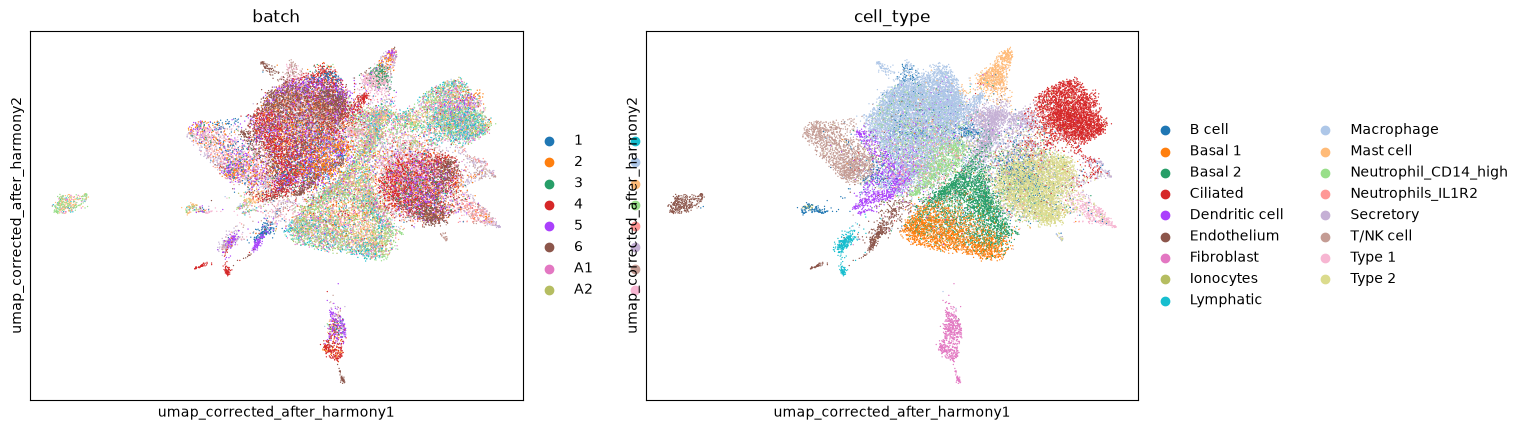

In [42]:
sc.pl.embedding(anndata, basis="umap_corrected_after_harmony", color=["batch", "cell_type"], palette=sc.pl.palettes.vega_20_scanpy)
# UMAP after batch correction via bibola, starting from harmony

/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


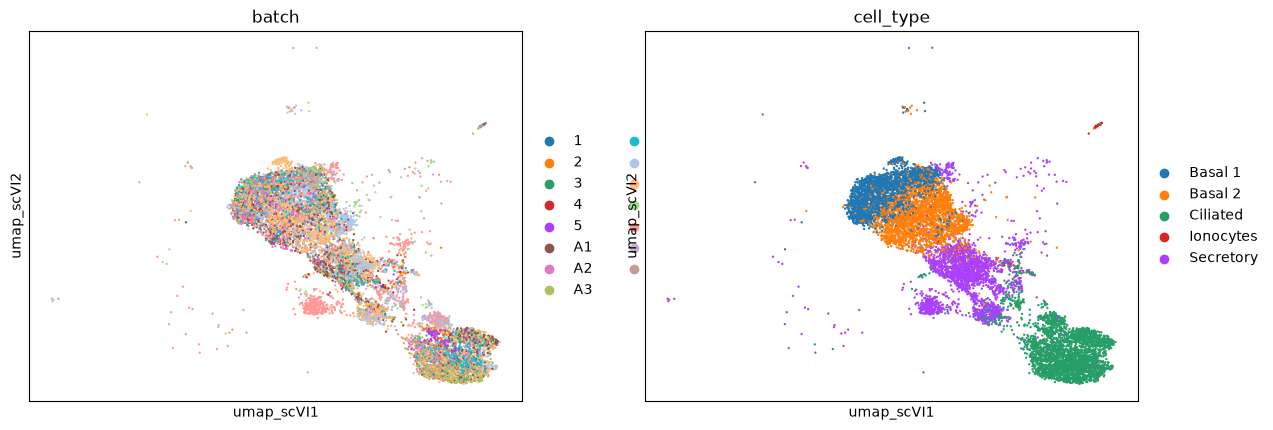

/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


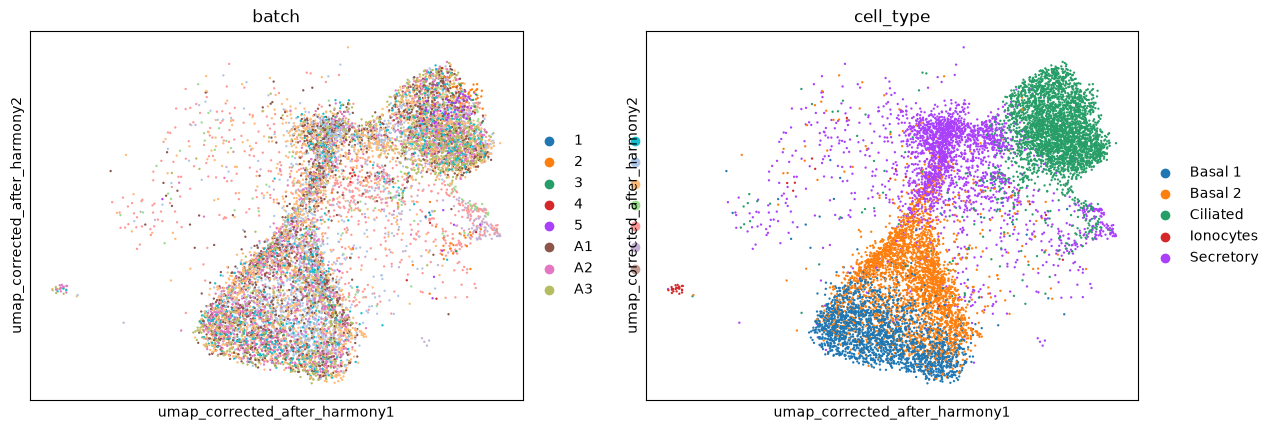

In [44]:
sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["Basal 1", "Basal 2", "Secretory", "Ciliated", "Ionocytes"])],
    basis="umap_scVI",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["Basal 1", "Basal 2", "Secretory", "Ciliated", "Ionocytes"])],
    basis="umap_corrected_after_harmony",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

# Basal
# ├── Basal 1
# ├── Basal 2
# │
# ├── Secretory
# │     └── Ciliated
# │
# └── Ionocytes
pass


/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


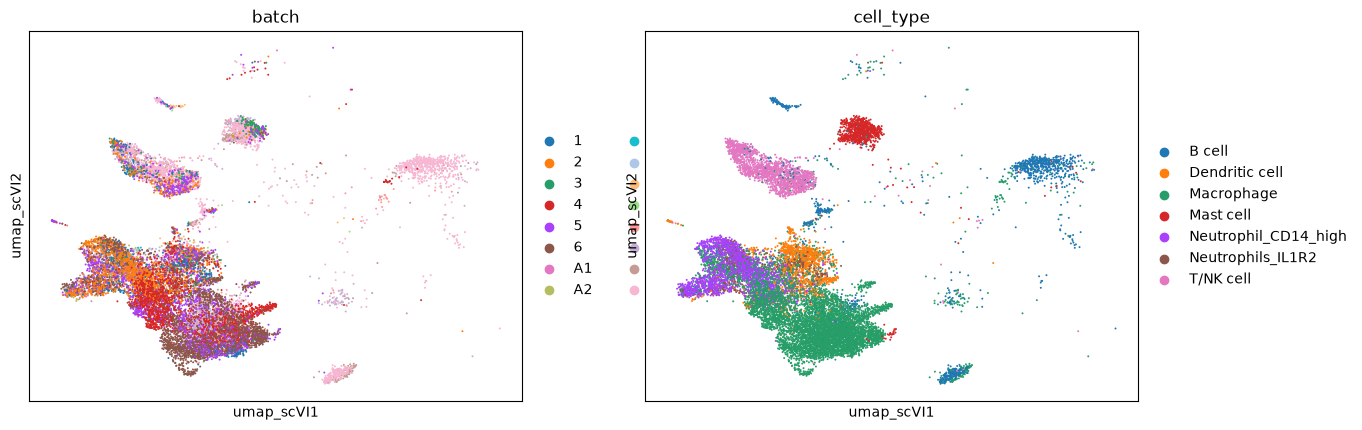

/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


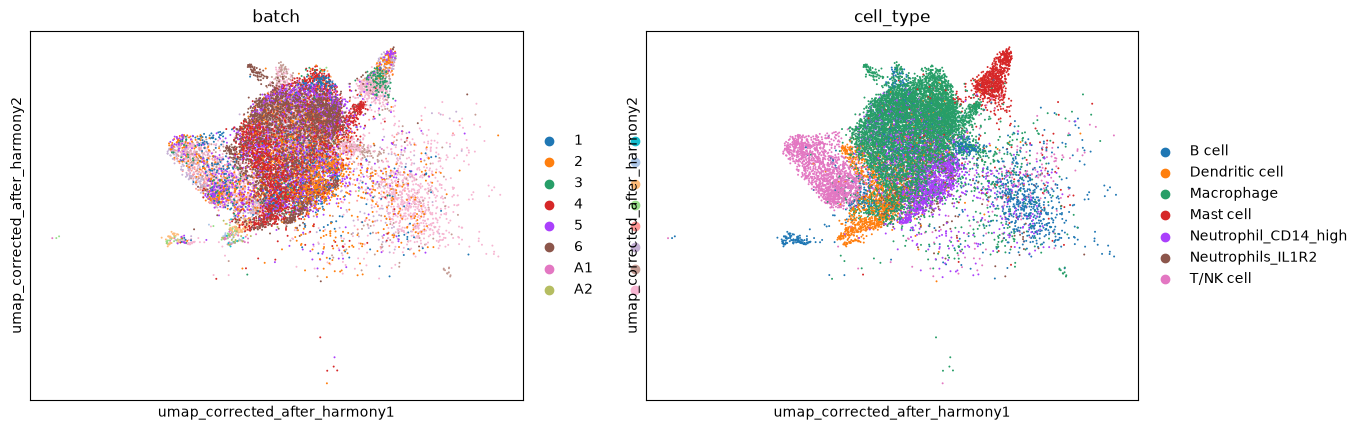

In [45]:
sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["B cell", "T/NK cell", "Neutrophils_IL1R2", "Neutrophil_CD14_high", "Macrophage", "Dendritic cell", "Mast cell"])],
    basis="umap_scVI",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["B cell", "T/NK cell", "Neutrophils_IL1R2", "Neutrophil_CD14_high", "Macrophage", "Dendritic cell", "Mast cell"])],
    basis="umap_corrected_after_harmony",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

# HSC
# ├── Lymphoid
# │     ├── B cell
# │     └── T/NK cell
# │
# └── Myeloid
#       ├── Neutrophils_IL1R2
#       ├── Neutrophil_CD14_high
#       ├── Macrophage
#       ├── Dendritic cell
#       └── Mast cell
pass


/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


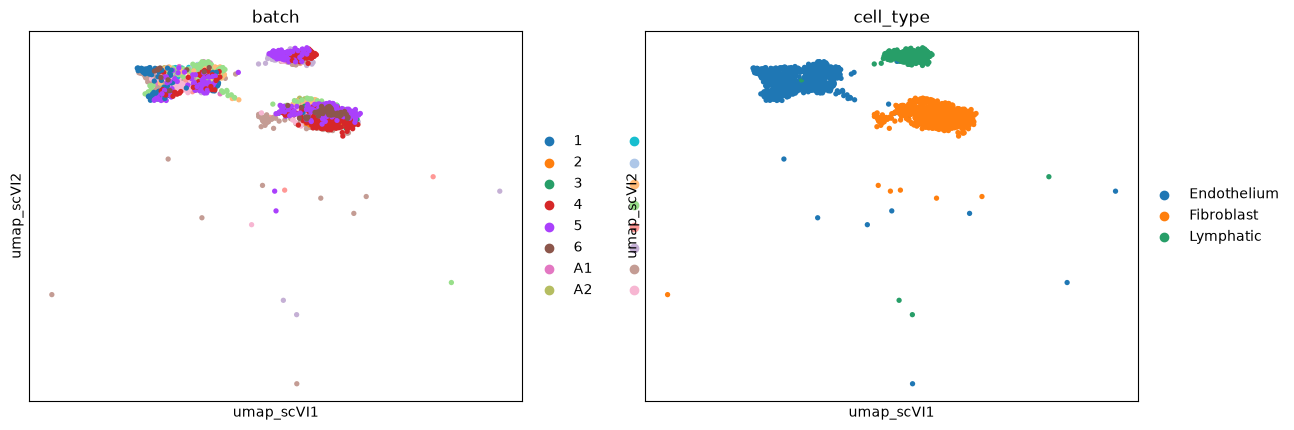

/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


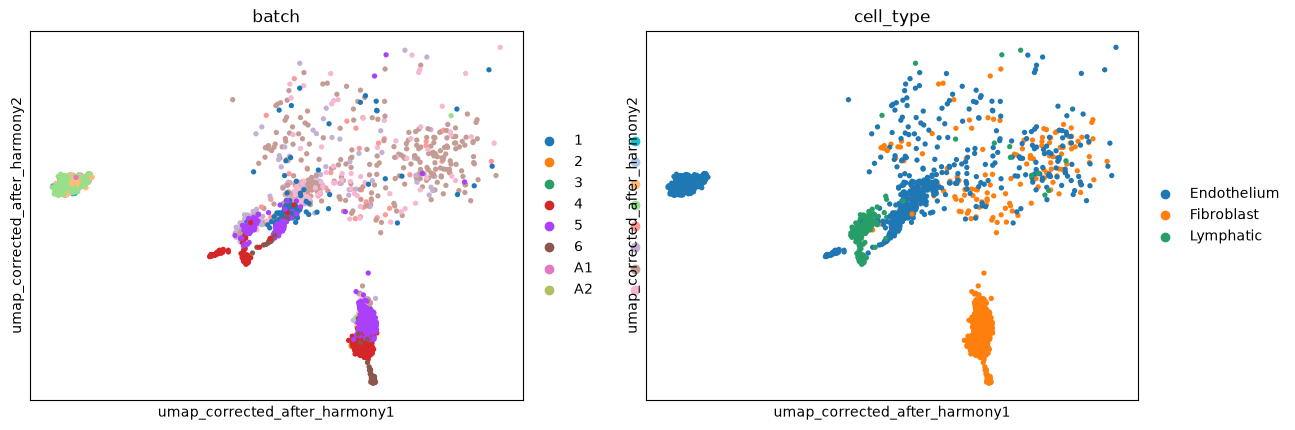

In [46]:
sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["Fibroblast", "Endothelium", "Lymphatic"])],
    basis="umap_scVI",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["Fibroblast", "Endothelium", "Lymphatic"])],
    basis="umap_corrected_after_harmony",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

# Mesenchymal progenitor
#       └── Fibroblast

# Endothelial progenitor
#       ├── Endothelium
#       └── Lymphatic endothelium
pass


/tmp/ipykernel_1125653/2405925517.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_types = anndata.obs.groupby(["batch", "cell_type"]).size().unstack(fill_value=0)


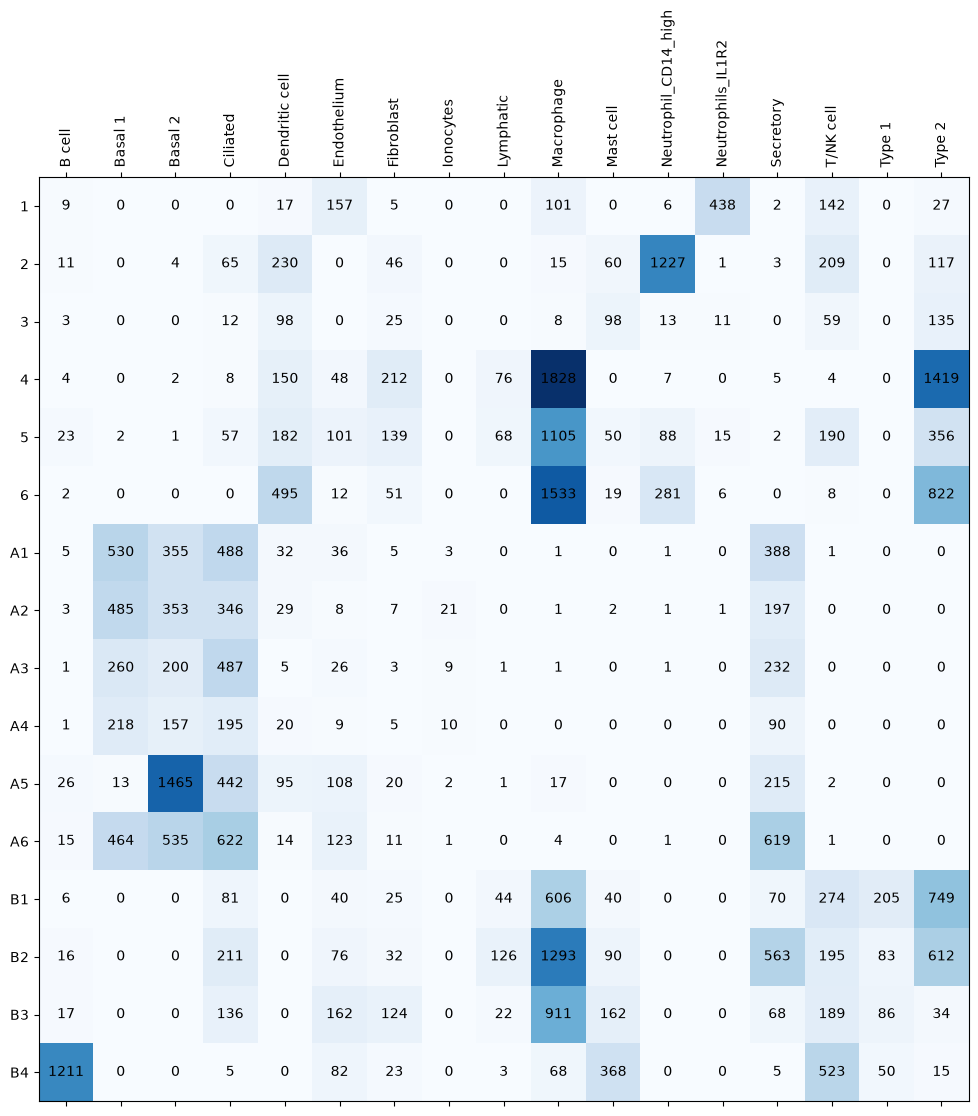

In [52]:
from matplotlib import pyplot as plt
import numpy as np

batch_types = anndata.obs.groupby(["batch", "cell_type"]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 12))
plt.matshow(batch_types, cmap="Blues", aspect="auto", fignum=0)
for (i, j), val in np.ndenumerate(batch_types.values):
    plt.text(j, i, val, ha='center', va='center', color='black')
plt.xticks(range(len(batch_types.columns)), batch_types.columns, rotation=90)
plt.yticks(range(len(batch_types.index)), batch_types.index)
plt.show()